In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/Sample - Superstore.csv', encoding='latin-1')
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days

In [3]:
#Region sales and profit
region_summary=df.groupby('region')[['sales','profit']].sum().reset_index()
region_summary

,region,sales,profit
0,Central,501239.8908,39706.3625
1,East,678781.2400,91522.7800
2,South,391721.9050,46749.4303
3,West,725457.8245,108418.4489


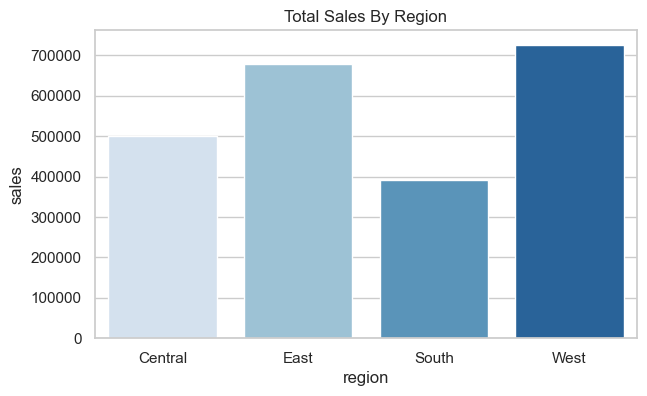

In [4]:
#Plot region sales
plt.figure(figsize=(7,4))
sns.barplot(data=region_summary,x='region',y='sales',palette='Blues', legend=False,hue='region')
plt.title('Total Sales By Region')
plt.savefig('../visuals/total_sales_by_region.png',dpi=150,bbox_inches='tight')
plt.show()

West leads with ~725K, followed by East at ~680K. Central and South lag behind. This is Business Question 2 answered: West and East are the top-performing regions. South needs investigation — is it low orders or low order value?

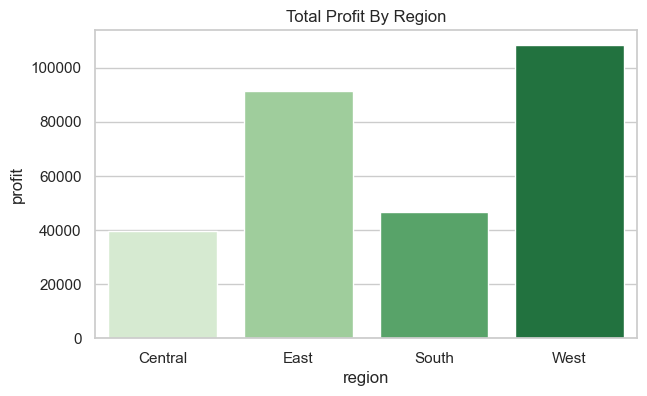

In [5]:
#Plot region profit
plt.figure(figsize=(7,4))
sns.barplot(data=region_summary,x='region',y='profit',palette='Greens', legend=False,hue='region')
plt.title('Total Profit By Region')
plt.savefig('../visuals/total_profit_by_region.png',dpi=150,bbox_inches='tight')
plt.show()

Central is generating more revenue but losing efficiency somewhere — likely heavy discounting or high-cost products being sold at thin margins.

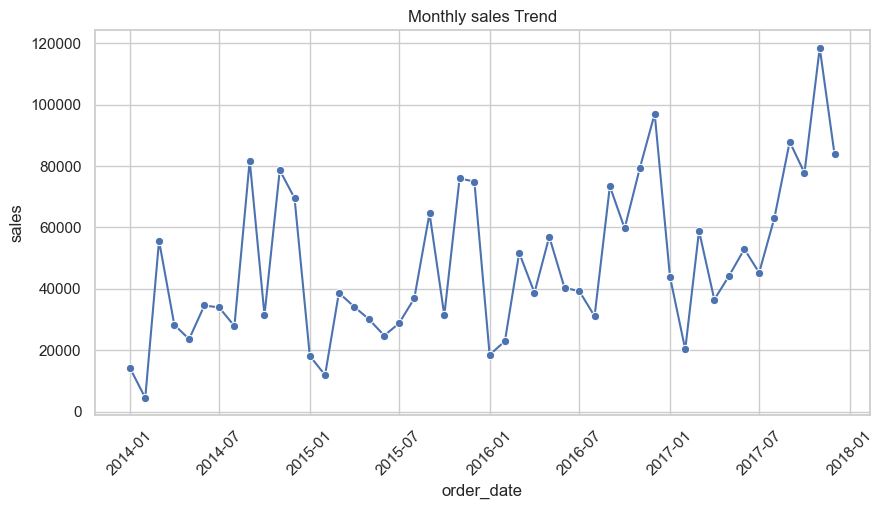

In [5]:
#Monthly sales trend
monthly_sales=df.groupby(df['order_date'].dt.to_period('M'))['sales'].sum().reset_index()
monthly_sales['order_date']=monthly_sales['order_date'].dt.to_timestamp()

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales,x='order_date',y='sales',marker='o')
plt.title('Monthly sales Trend')
plt.xticks(rotation=45)
plt.savefig('../visuals/montly_sales_trend.png',dpi=150,bbox_inches='tight')
plt.show()

Sales show a clear upward trend from 2014 to 2017, with recurring dips in January/February each year — classic post-holiday slowdown. The highest spike is November 2017 (~118K), suggesting strong year-end sales. This is a seasonality pattern worth highlighting.

C:\Users\Mohammed Yousuf\AppData\Local\Temp\ipykernel_17972\3914591466.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ship_mode_counts,x='ship_mode',y='count',palette="Set2")


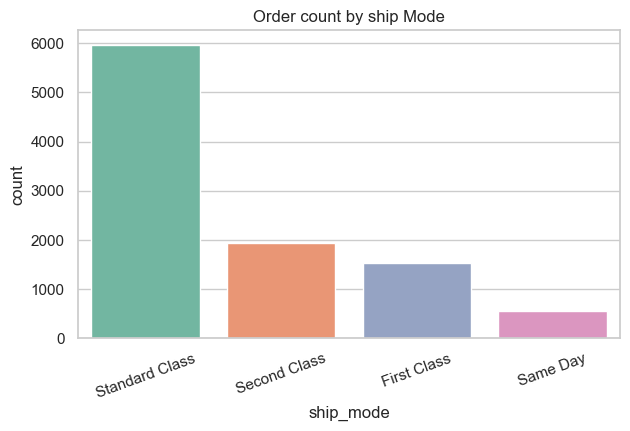

In [7]:
#Ship mode count
ship_mode_counts=df['ship_mode'].value_counts().reset_index()
ship_mode_counts.columns=['ship_mode','count']

plt.figure(figsize=(7,4))
sns.barplot(data=ship_mode_counts,x='ship_mode',y='count',palette="Set2")
plt.title("Order count by ship Mode")
plt.xticks(rotation=20)
plt.savefig('../visuals/order_count_by_ship_mode.png',dpi=150,bbox_inches='tight')
plt.show()

Standard Class dominates with ~6000 orders — that's 60% of all orders. Same Day is barely used (~550). This tells us customers prefer economy over speed, which has logistics cost implications

In [7]:
df['shipping_days']=(df['ship_date']-df['order_date']).dt.days
df[['shipping_days','sales','profit']].describe()

,shipping_days,sales,profit
count,9994.000000,9994.000000,9994.000000
mean,3.958175,229.858001,28.656896
std,1.747567,623.245101,234.260108
min,0.000000,0.444000,-6599.978000
25%,3.000000,17.280000,1.728750
50%,4.000000,54.490000,8.666500
75%,5.000000,209.940000,29.364000
max,7.000000,22638.480000,8399.976000


## 2.Which region has highest sales?
#### West, followed by East

## 3.What ship mode do customers prefer?
#### Standard Class (60% of orders)